In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
df = pd.read_excel("Nassau Candy Distributor.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 10194
Columns: 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01 00:00:00,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01 00:00:00,2026-01-07 00:00:00,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01 00:00:00,2026-01-07 00:00:00,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01 00:00:00,2026-01-07 00:00:00,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01 00:00:00,2026-05-07 00:00:00,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
def parse_date(x):
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, pd.Timestamp):
        return x
    if hasattr(x, "year") and hasattr(x, "month") and hasattr(x, "day"):
        return pd.Timestamp(x)
    x = str(x).strip()
    if len(x) >= 10 and x[4] == "-":
        return pd.to_datetime(x, format="%Y-%m-%d", errors="coerce")
    return pd.to_datetime(x, format="%d-%m-%Y", errors="coerce")

df_clean = df.copy()

df_clean["Order Date"] = df_clean["Order Date"].apply(parse_date)
df_clean["Ship Date"] = df_clean["Ship Date"].apply(parse_date)

df_clean["Profit Margin (%)"] = np.where(
    df_clean["Sales"] != 0,
    (df_clean["Gross Profit"] / df_clean["Sales"]) * 100,
    0
)

df_clean["Profit per Unit"] = np.where(
    df_clean["Units"] != 0,
    df_clean["Gross Profit"] / df_clean["Units"],
    0
)

df_clean["Revenue per Unit"] = np.where(
    df_clean["Units"] != 0,
    df_clean["Sales"] / df_clean["Units"],
    0
)

df_clean["Cost per Unit"] = np.where(
    df_clean["Units"] != 0,
    df_clean["Cost"] / df_clean["Units"],
    0
)

df_clean["Cost Ratio (%)"] = np.where(
    df_clean["Sales"] != 0,
    (df_clean["Cost"] / df_clean["Sales"]) * 100,
    0
)

df_clean["Order Year"] = df_clean["Order Date"].dt.year
df_clean["Order Month"] = df_clean["Order Date"].dt.month
df_clean["Order Month Name"] = df_clean["Order Date"].dt.month_name()

print("Data cleaning completed!")
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Missing Values:", df_clean.isnull().sum().sum())

display(df_clean.head())

Data cleaning completed!
Rows: 10194
Columns: 26
Missing Values: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Gross Profit,Cost,Profit Margin (%),Profit per Unit,Revenue per Unit,Cost per Unit,Cost Ratio (%),Order Year,Order Month,Order Month Name
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,4.22,2.28,64.923077,2.11,3.25,1.14,35.076923,2024,3,March
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,...,4.90,2.60,65.333333,2.45,3.75,1.30,34.666667,2024,4,April
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.47,3.00,71.346705,2.49,3.49,1.00,28.653295,2024,4,April
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.50,3.30,69.444444,2.50,3.60,1.10,30.555556,2024,4,April
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-05-07,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,7.35,3.90,65.333333,2.45,3.75,1.30,34.666667,2024,5,May


In [5]:
print("DATA QUALITY VALIDATION")
print("=" * 50)

print("Duplicate Rows:", df_clean.duplicated().sum())
print("Sales <= 0:", (df_clean["Sales"] <= 0).sum())
print("Cost <= 0:", (df_clean["Cost"] <= 0).sum())
print("Units <= 0:", (df_clean["Units"] <= 0).sum())

profit_check = (
    df_clean["Sales"]
    - df_clean["Cost"]
    - df_clean["Gross Profit"]
).abs()

print("Profit Calculation Errors:", (profit_check > 0.01).sum())

print("Unique Products:", df_clean["Product Name"].nunique())
print("Unique Customers:", df_clean["Customer ID"].nunique())
print("Unique Cities:", df_clean["City"].nunique())
print("Unique States/Provinces:", df_clean["State/Province"].nunique())

print("Invalid Order Dates:", df_clean["Order Date"].isna().sum())
print("Invalid Ship Dates:", df_clean["Ship Date"].isna().sum())

DATA QUALITY VALIDATION
Duplicate Rows: 0
Sales <= 0: 0
Cost <= 0: 0
Units <= 0: 0
Profit Calculation Errors: 0
Unique Products: 15
Unique Customers: 5044
Unique Cities: 542
Unique States/Provinces: 59
Invalid Order Dates: 0
Invalid Ship Dates: 0


In [6]:
factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar - Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Kazookles": "The Other Factory"
}

df_clean["Origin Factory"] = df_clean["Product Name"].map(factory_mapping)

print("Product-to-factory mapping completed!")
print("Unmapped Products:", df_clean["Origin Factory"].isna().sum())

display(
    df_clean[["Product Name", "Origin Factory"]]
    .drop_duplicates()
    .sort_values("Origin Factory")
)

Product-to-factory mapping completed!
Unmapped Products: 0


,Product Name,Origin Factory
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
13,Wonka Bar - Fudge Mallows,Lot's O' Nuts
19,Wonka Gum,Secret Factory
136,Lickable Wallpaper,Secret Factory
4729,Everlasting Gobstopper,Secret Factory
191,Fizzy Lifting Drinks,Sugar Shack
226,Laffy Taffy,Sugar Shack
973,SweeTARTS,Sugar Shack
1490,Nerds,Sugar Shack


In [7]:
factory_coordinates = {
    "Lot's O' Nuts": {"Latitude": 32.881893, "Longitude": -111.768036},
    "Wicked Choccy's": {"Latitude": 32.076176, "Longitude": -81.088371},
    "Sugar Shack": {"Latitude": 48.119140, "Longitude": -96.181150},
    "Secret Factory": {"Latitude": 41.446333, "Longitude": -90.565487},
    "The Other Factory": {"Latitude": 35.117500, "Longitude": -89.971107}
}

df_clean["Factory Latitude"] = df_clean["Origin Factory"].map(
    lambda x: factory_coordinates[x]["Latitude"]
)

df_clean["Factory Longitude"] = df_clean["Origin Factory"].map(
    lambda x: factory_coordinates[x]["Longitude"]
)

print("Factory coordinates added successfully!")
display(
    pd.DataFrame(factory_coordinates).T
)

Factory coordinates added successfully!


,Latitude,Longitude
Lot's O' Nuts,32.881893,-111.768036
Wicked Choccy's,32.076176,-81.088371
Sugar Shack,48.119140,-96.181150
Secret Factory,41.446333,-90.565487
The Other Factory,35.117500,-89.971107


In [8]:
state_coordinates = {
    "Alabama": (32.806671, -86.791130),
    "Alaska": (61.370716, -152.404419),
    "Arizona": (33.729759, -111.431221),
    "Arkansas": (34.969704, -92.373123),
    "California": (36.116203, -119.681564),
    "Colorado": (39.059811, -105.311104),
    "Connecticut": (41.597782, -72.755371),
    "Delaware": (39.318523, -75.507141),
    "Florida": (27.766279, -81.686783),
    "Georgia": (33.040619, -83.643074),
    "Idaho": (44.240459, -114.478828),
    "Illinois": (40.349457, -88.986137),
    "Indiana": (39.849426, -86.258278),
    "Iowa": (42.011539, -93.210526),
    "Kansas": (38.526600, -96.726486),
    "Kentucky": (37.668140, -84.670067),
    "Louisiana": (31.169546, -91.867805),
    "Maine": (44.693947, -69.381927),
    "Maryland": (39.063946, -76.802101),
    "Massachusetts": (42.230171, -71.530106),
    "Michigan": (43.326618, -84.536095),
    "Minnesota": (45.694454, -93.900192),
    "Mississippi": (32.741646, -89.678696),
    "Missouri": (38.456085, -92.288368),
    "Montana": (46.921925, -110.454353),
    "Nebraska": (41.125370, -98.268082),
    "Nevada": (38.313515, -117.055374),
    "New Hampshire": (43.452492, -71.563896),
    "New Jersey": (40.298904, -74.521011),
    "New Mexico": (34.840515, -106.248482),
    "New York": (42.165726, -74.948051),
    "North Carolina": (35.630066, -79.806419),
    "North Dakota": (47.528912, -99.784012),
    "Ohio": (40.388783, -82.764915),
    "Oklahoma": (35.565342, -96.928917),
    "Oregon": (44.572021, -122.070938),
    "Pennsylvania": (40.590752, -77.209755),
    "Rhode Island": (41.680893, -71.511780),
    "South Carolina": (33.856892, -80.945007),
    "South Dakota": (44.299782, -99.438828),
    "Tennessee": (35.747845, -86.692345),
    "Texas": (31.054487, -97.563461),
    "Utah": (40.150032, -111.862434),
    "Vermont": (44.045876, -72.710686),
    "Virginia": (37.769337, -78.169968),
    "Washington": (47.400902, -121.490494),
    "West Virginia": (38.491226, -80.954456),
    "Wisconsin": (44.268543, -89.616508),
    "Wyoming": (42.755966, -107.302490),
    "District of Columbia": (38.897438, -77.026817)
}

canada_coordinates = {
    "Ontario": (51.2538, -85.3232),
    "Quebec": (52.9399, -73.5491),
    "Alberta": (53.9333, -116.5765),
    "British Columbia": (53.7267, -127.6476),
    "Manitoba": (53.7609, -98.8139),
    "Prince Edward Island": (46.5107, -63.4168),
    "New Brunswick": (46.5653, -66.4619),
    "Nova Scotia": (44.6820, -63.7443),
    "Newfoundland and Labrador": (53.1355, -57.6604),
    "Saskatchewan": (52.9399, -106.4509)
}

df_clean["Destination Latitude"] = df_clean["State/Province"].map(
    lambda x: state_coordinates.get(
        x,
        canada_coordinates.get(x, (np.nan, np.nan))
    )[0]
)

df_clean["Destination Longitude"] = df_clean["State/Province"].map(
    lambda x: state_coordinates.get(
        x,
        canada_coordinates.get(x, (np.nan, np.nan))
    )[1]
)

print("Destination coordinates added successfully!")
print("Missing Latitude:", df_clean["Destination Latitude"].isna().sum())
print("Missing Longitude:", df_clean["Destination Longitude"].isna().sum())

Destination coordinates added successfully!
Missing Latitude: 0
Missing Longitude: 0


In [9]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371 * c

df_clean["Current Distance (km)"] = haversine_distance(
    df_clean["Factory Latitude"],
    df_clean["Factory Longitude"],
    df_clean["Destination Latitude"],
    df_clean["Destination Longitude"]
)

print("Distance calculation completed!")
print(
    "Average Current Distance:",
    round(df_clean["Current Distance (km)"].mean(), 2),
    "km"
)

display(
    df_clean[
        [
            "Product Name",
            "Origin Factory",
            "State/Province",
            "Current Distance (km)"
        ]
    ].head()
)

Distance calculation completed!
Average Current Distance: 1995.66 km


,Product Name,Origin Factory,State/Province,Current Distance (km)
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Texas,1563.505335
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Illinois,1160.081298
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Illinois,2188.313441
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Illinois,2188.313441
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Pennsylvania,1008.215443


In [10]:
factory_names = list(factory_coordinates.keys())

for factory in factory_names:
    lat = factory_coordinates[factory]["Latitude"]
    lon = factory_coordinates[factory]["Longitude"]
    
    df_clean[f"Distance - {factory} (km)"] = haversine_distance(
        lat,
        lon,
        df_clean["Destination Latitude"],
        df_clean["Destination Longitude"]
    )

distance_columns = [
    f"Distance - {factory} (km)"
    for factory in factory_names
]

df_clean["Nearest Factory"] = df_clean[distance_columns].idxmin(axis=1)

df_clean["Nearest Factory"] = (
    df_clean["Nearest Factory"]
    .str.replace("Distance - ", "", regex=False)
    .str.replace(" (km)", "", regex=False)
)

df_clean["Distance to Nearest Factory (km)"] = (
    df_clean[distance_columns].min(axis=1)
)

print("Alternative factory distances calculated!")
print("Factories evaluated:", len(factory_names))

display(
    df_clean[
        [
            "Product Name",
            "Origin Factory",
            "Current Distance (km)",
            "Nearest Factory",
            "Distance to Nearest Factory (km)"
        ]
    ].head()
)

Alternative factory distances calculated!
Factories evaluated: 5


,Product Name,Origin Factory,Current Distance (km),Nearest Factory,Distance to Nearest Factory (km)
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,1563.505335,The Other Factory,838.896266
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,1160.081298,Secret Factory,180.262845
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,2188.313441,Secret Factory,180.262845
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,2188.313441,Secret Factory,180.262845
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,1008.215443,Wicked Choccy's,1008.215443


In [11]:
df_clean["Potential Distance Saving (km)"] = (
    df_clean["Current Distance (km)"]
    - df_clean["Distance to Nearest Factory (km)"]
)

df_clean["Potential Distance Reduction (%)"] = np.where(
    df_clean["Current Distance (km)"] > 0,
    (
        df_clean["Potential Distance Saving (km)"]
        / df_clean["Current Distance (km)"]
    ) * 100,
    0
)

df_clean["Potential Distance Saving (km)"] = (
    df_clean["Potential Distance Saving (km)"].clip(lower=0)
)

df_clean["Potential Distance Reduction (%)"] = (
    df_clean["Potential Distance Reduction (%)"].clip(lower=0)
)

print("Potential distance savings calculated!")

print(
    "Average Potential Distance Saving:",
    round(df_clean["Potential Distance Saving (km)"].mean(), 2),
    "km"
)

print(
    "Average Potential Distance Reduction:",
    round(df_clean["Potential Distance Reduction (%)"].mean(), 2),
    "%"
)

display(
    df_clean[
        [
            "Product Name",
            "Origin Factory",
            "Nearest Factory",
            "Current Distance (km)",
            "Distance to Nearest Factory (km)",
            "Potential Distance Saving (km)",
            "Potential Distance Reduction (%)"
        ]
    ].head()
)

Potential distance savings calculated!
Average Potential Distance Saving: 1167.72 km
Average Potential Distance Reduction: 44.95 %


,Product Name,Origin Factory,Nearest Factory,Current Distance (km),Distance to Nearest Factory (km),Potential Distance Saving (km),Potential Distance Reduction (%)
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,1563.505335,838.896266,724.609070,46.345161
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,1160.081298,180.262845,979.818453,84.461189
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Secret Factory,2188.313441,180.262845,2008.050597,91.762476
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Secret Factory,2188.313441,180.262845,2008.050597,91.762476
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's,1008.215443,1008.215443,0.000000,0.000000


In [12]:
reallocation_records = []

for _, row in df_clean.iterrows():
    product = row["Product Name"]
    current_factory = row["Origin Factory"]
    current_distance = row["Current Distance (km)"]

    for factory in factory_names:
        if factory == current_factory:
            continue

        alternative_distance = row[f"Distance - {factory} (km)"]

        distance_saving = current_distance - alternative_distance

        distance_reduction = (
            distance_saving / current_distance * 100
            if current_distance > 0 else 0
        )

        reallocation_records.append({
            "Order ID": row["Order ID"],
            "Product Name": product,
            "Current Factory": current_factory,
            "Alternative Factory": factory,
            "Current Distance (km)": current_distance,
            "Alternative Distance (km)": alternative_distance,
            "Distance Saving (km)": distance_saving,
            "Distance Reduction (%)": distance_reduction,
            "Sales": row["Sales"],
            "Gross Profit": row["Gross Profit"],
            "Profit Margin (%)": row["Profit Margin (%)"],
            "Units": row["Units"],
            "Ship Mode": row["Ship Mode"],
            "Region": row["Region"]
        })

reallocation_df = pd.DataFrame(reallocation_records)

print("Factory reallocation scenarios created!")
print("Scenario records:", len(reallocation_df))

display(reallocation_df.head())

Factory reallocation scenarios created!
Scenario records: 40776


,Order ID,Product Name,Current Factory,Alternative Factory,Current Distance (km),Alternative Distance (km),Distance Saving (km),Distance Reduction (%),Sales,Gross Profit,Profit Margin (%),Units,Ship Mode,Region
0,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1563.505335,1354.179360,209.325976,13.388248,6.5,4.22,64.923077,2,Standard Class,Interior
1,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,1563.505335,1901.112863,-337.607528,-21.592989,6.5,4.22,64.923077,2,Standard Class,Interior
2,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,1563.505335,1313.778918,249.726417,15.972214,6.5,4.22,64.923077,2,Standard Class,Interior
3,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,1563.505335,838.896266,724.609070,46.345161,6.5,4.22,64.923077,2,Standard Class,Interior
4,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1160.081298,2188.313441,-1028.232143,-88.634490,7.5,4.90,65.333333,2,Standard Class,Interior


In [13]:
recommendation_df = reallocation_df[
    reallocation_df["Distance Saving (km)"] > 0
].copy()

recommendation_df["Profit Stability (%)"] = (
    recommendation_df["Profit Margin (%)"]
)

recommendation_df["Scenario Confidence Score"] = np.where(
    recommendation_df["Distance Reduction (%)"] >= 50,
    0.90,
    np.where(
        recommendation_df["Distance Reduction (%)"] >= 25,
        0.80,
        np.where(
            recommendation_df["Distance Reduction (%)"] > 0,
            0.70,
            0
        )
    )
)

recommendation_df["Recommendation Score"] = (
    recommendation_df["Distance Reduction (%)"] * 0.50
    + recommendation_df["Profit Stability (%)"] * 0.30
    + recommendation_df["Scenario Confidence Score"] * 100 * 0.20
)

recommendation_df = recommendation_df.sort_values(
    "Recommendation Score",
    ascending=False
).reset_index(drop=True)

print("Recommendation candidates generated!")
print("Candidate scenarios:", len(recommendation_df))

display(
    recommendation_df[
        [
            "Product Name",
            "Current Factory",
            "Alternative Factory",
            "Distance Saving (km)",
            "Distance Reduction (%)",
            "Profit Margin (%)",
            "Scenario Confidence Score",
            "Recommendation Score"
        ]
    ].head(10)
)

Recommendation candidates generated!
Candidate scenarios: 23889


,Product Name,Current Factory,Alternative Factory,Distance Saving (km),Distance Reduction (%),Profit Margin (%),Scenario Confidence Score,Recommendation Score
0,Hair Toffee,The Other Factory,Lot's O' Nuts,1871.261834,94.958980,77.777778,0.9,88.812824
1,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2655.213014,93.045529,71.346705,0.9,85.926776
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2655.213014,93.045529,71.346705,0.9,85.926776
3,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2655.213014,93.045529,71.346705,0.9,85.926776
4,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2655.213014,93.045529,71.346705,0.9,85.926776
5,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2655.213014,93.045529,71.346705,0.9,85.926776
6,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2655.213014,93.045529,71.346705,0.9,85.926776
7,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2655.213014,93.045529,71.346705,0.9,85.926776
8,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,2729.224896,96.488028,65.333333,0.9,85.844014
9,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,2729.224896,96.488028,65.333333,0.9,85.844014


In [14]:
product_recommendations = (
    recommendation_df
    .groupby(
        [
            "Product Name",
            "Current Factory",
            "Alternative Factory"
        ],
        as_index=False
    )
    .agg(
        Orders=("Order ID", "nunique"),
        Avg_Distance_Saving_km=("Distance Saving (km)", "mean"),
        Total_Distance_Saving_km=("Distance Saving (km)", "sum"),
        Avg_Distance_Reduction_pct=("Distance Reduction (%)", "mean"),
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Avg_Profit_Margin_pct=("Profit Margin (%)", "mean"),
        Avg_Confidence=("Scenario Confidence Score", "mean"),
        Avg_Recommendation_Score=("Recommendation Score", "mean")
    )
    .sort_values(
        "Avg_Recommendation_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Product-level recommendation analysis completed!")

display(product_recommendations.head(10))

Product-level recommendation analysis completed!


,Product Name,Current Factory,Alternative Factory,Orders,Avg_Distance_Saving_km,Total_Distance_Saving_km,Avg_Distance_Reduction_pct,Total_Sales,Total_Gross_Profit,Avg_Profit_Margin_pct,Avg_Confidence,Avg_Recommendation_Score
0,Fizzy Lifting Drinks,Sugar Shack,Lot's O' Nuts,1,1942.552496,1.942552e+03,95.134983,11.25,6.75,60.000000,0.900000,83.567491
1,Hair Toffee,The Other Factory,Lot's O' Nuts,2,1869.820434,3.739641e+03,82.370156,45.00,35.00,77.777778,0.900000,82.518412
2,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,1,1239.556339,1.239556e+03,71.973105,40.00,32.00,80.000000,0.900000,77.986552
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,944,1914.028850,2.187735e+06,64.581899,15570.00,10812.50,69.444444,0.883902,70.802323
4,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,862,1843.082890,1.898375e+06,63.522585,13572.61,9683.61,71.346705,0.878252,70.730352
5,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,870,1880.028657,1.958990e+06,63.777522,14014.80,9343.20,66.666667,0.881766,69.524078
6,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,The Other Factory,1046,1582.801296,1.959508e+06,60.000188,16190.11,11551.11,71.346705,0.881422,69.032538
7,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,1144,1586.117768,2.207876e+06,58.820938,18990.00,13187.50,69.444444,0.880101,67.845814
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Secret Factory,1048,1580.911070,1.960330e+06,57.363654,16218.03,11571.03,71.346705,0.864032,67.366484
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,1046,1590.712745,1.986800e+06,59.113511,16866.00,11244.00,66.666667,0.881265,67.182056


In [15]:
ship_mode_params = {
    "Same Day": {
        "base_days": 1,
        "km_per_day": 1200
    },
    "First Class": {
        "base_days": 2,
        "km_per_day": 900
    },
    "Second Class": {
        "base_days": 3,
        "km_per_day": 700
    },
    "Standard Class": {
        "base_days": 5,
        "km_per_day": 500
    }
}

df_ml = df_clean.copy()

df_ml["Scenario Lead Time (days)"] = df_ml.apply(
    lambda row: (
        ship_mode_params.get(
            row["Ship Mode"],
            {"base_days": 5, "km_per_day": 500}
        )["base_days"]
        +
        row["Current Distance (km)"] /
        ship_mode_params.get(
            row["Ship Mode"],
            {"base_days": 5, "km_per_day": 500}
        )["km_per_day"]
    ),
    axis=1
)

print("Scenario lead time calculated!")

display(
    df_ml[
        [
            "Product Name",
            "Origin Factory",
            "Region",
            "Ship Mode",
            "Current Distance (km)",
            "Scenario Lead Time (days)"
        ]
    ].head()
)

Scenario lead time calculated!


,Product Name,Origin Factory,Region,Ship Mode,Current Distance (km),Scenario Lead Time (days)
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,1563.505335,8.127011
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Standard Class,1160.081298,7.320163
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,Standard Class,2188.313441,9.376627
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,Standard Class,2188.313441,9.376627
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,1008.215443,7.016431


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

features = [
    "Product Name",
    "Origin Factory",
    "Region",
    "Ship Mode"
]

X = df_ml[features]
y = df_ml["Scenario Lead Time (days)"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

categorical_features = [
    "Product Name",
    "Origin Factory",
    "Region",
    "Ship Mode"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

model_results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    model_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    trained_models[name] = pipeline

model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

best_model_name = model_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Model comparison completed!")
print("Best Model:", best_model_name)

display(model_results_df)

Model comparison completed!
Best Model: Random Forest


,Model,RMSE,MAE,R2
0,Random Forest,0.668458,0.489851,0.946014
1,Gradient Boosting,0.868204,0.685291,0.908930
2,Linear Regression,1.804075,1.540248,0.606774


In [17]:
scenario_df = recommendation_df.copy()

scenario_df["Current Lead Time (days)"] = scenario_df.apply(
    lambda row: (
        ship_mode_params.get(
            row["Ship Mode"],
            {"base_days": 5, "km_per_day": 500}
        )["base_days"]
        +
        row["Current Distance (km)"] /
        ship_mode_params.get(
            row["Ship Mode"],
            {"base_days": 5, "km_per_day": 500}
        )["km_per_day"]
    ),
    axis=1
)

scenario_df["Alternative Lead Time (days)"] = scenario_df.apply(
    lambda row: (
        ship_mode_params.get(
            row["Ship Mode"],
            {"base_days": 5, "km_per_day": 500}
        )["base_days"]
        +
        row["Alternative Distance (km)"] /
        ship_mode_params.get(
            row["Ship Mode"],
            {"base_days": 5, "km_per_day": 500}
        )["km_per_day"]
    ),
    axis=1
)

scenario_df["Lead Time Saving (days)"] = (
    scenario_df["Current Lead Time (days)"]
    - scenario_df["Alternative Lead Time (days)"]
)

scenario_df["Lead Time Reduction (%)"] = np.where(
    scenario_df["Current Lead Time (days)"] > 0,
    (
        scenario_df["Lead Time Saving (days)"]
        / scenario_df["Current Lead Time (days)"]
    ) * 100,
    0
)

scenario_df["Lead Time Reduction (%)"] = (
    scenario_df["Lead Time Reduction (%)"].clip(0, 100)
)

final_recommendations = scenario_df.copy()

final_recommendations["Lead Time Score"] = (
    final_recommendations["Lead Time Reduction (%)"].clip(0, 100)
)

final_recommendations["Distance Score"] = (
    final_recommendations["Distance Reduction (%)"].clip(0, 100)
)

final_recommendations["Profit Score"] = (
    final_recommendations["Profit Margin (%)"].clip(0, 100)
)

final_recommendations["Confidence Score"] = (
    final_recommendations["Scenario Confidence Score"] * 100
)

final_recommendations["Final Recommendation Score"] = (
    final_recommendations["Lead Time Score"] * 0.35
    + final_recommendations["Distance Score"] * 0.30
    + final_recommendations["Profit Score"] * 0.20
    + final_recommendations["Confidence Score"] * 0.15
)

final_recommendations["Recommendation Level"] = np.select(
    [
        final_recommendations["Final Recommendation Score"] >= 80,
        final_recommendations["Final Recommendation Score"] >= 60,
        final_recommendations["Final Recommendation Score"] >= 40
    ],
    [
        "High Potential",
        "Moderate Potential",
        "Low Potential"
    ],
    default="Review Required"
)

final_recommendations = final_recommendations.sort_values(
    "Final Recommendation Score",
    ascending=False
).reset_index(drop=True)

print("Final recommendation engine completed!")

display(
    final_recommendations[
        [
            "Product Name",
            "Current Factory",
            "Alternative Factory",
            "Current Lead Time (days)",
            "Alternative Lead Time (days)",
            "Lead Time Saving (days)",
            "Lead Time Reduction (%)",
            "Distance Saving (km)",
            "Distance Reduction (%)",
            "Profit Margin (%)",
            "Final Recommendation Score",
            "Recommendation Level"
        ]
    ].head(10)
)

Final recommendation engine completed!


,Product Name,Current Factory,Alternative Factory,Current Lead Time (days),Alternative Lead Time (days),Lead Time Saving (days),Lead Time Reduction (%),Distance Saving (km),Distance Reduction (%),Profit Margin (%),Final Recommendation Score,Recommendation Level
0,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2729.224896,96.488028,65.333333,79.224474,Moderate Potential
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2729.224896,96.488028,65.333333,79.224474,Moderate Potential
2,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2729.224896,96.488028,65.333333,79.224474,Moderate Potential
3,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2729.224896,96.488028,65.333333,79.224474,Moderate Potential
4,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2729.224896,96.488028,64.923077,79.142423,Moderate Potential
5,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2729.224896,96.488028,64.923077,79.142423,Moderate Potential
6,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,3.378059,1.165381,2.212678,65.501448,2655.213014,93.045529,66.666667,77.672499,Moderate Potential
7,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,3.378059,1.165381,2.212678,65.501448,2655.213014,93.045529,66.666667,77.672499,Moderate Potential
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,3.180085,1.218613,1.961472,61.679866,2353.766907,89.972273,71.346705,76.348976,Moderate Potential
9,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,3.180085,1.218613,1.961472,61.679866,2353.766907,89.972273,71.346705,76.348976,Moderate Potential


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_df = (
    scenario_df
    .groupby(
        [
            "Product Name",
            "Region",
            "Ship Mode"
        ],
        as_index=False
    )
    .agg(
        Orders=("Order ID", "nunique"),
        Avg_Distance_km=("Current Distance (km)", "mean"),
        Avg_Lead_Time_days=("Current Lead Time (days)", "mean"),
        Avg_Lead_Time_Saving_days=("Lead Time Saving (days)", "mean"),
        Avg_Distance_Reduction_pct=("Distance Reduction (%)", "mean"),
        Avg_Profit_Margin_pct=("Profit Margin (%)", "mean")
    )
)

cluster_features = [
    "Avg_Distance_km",
    "Avg_Lead_Time_days",
    "Avg_Lead_Time_Saving_days",
    "Avg_Distance_Reduction_pct",
    "Avg_Profit_Margin_pct"
]

X_cluster = cluster_df[cluster_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Route Cluster"] = (
    kmeans.fit_predict(X_scaled)
)

cluster_summary = (
    cluster_df
    .groupby("Route Cluster")
    .agg(
        Route_Groups=("Product Name", "count"),
        Avg_Distance_km=("Avg_Distance_km", "mean"),
        Avg_Lead_Time_days=("Avg_Lead_Time_days", "mean"),
        Avg_Lead_Time_Saving_days=("Avg_Lead_Time_Saving_days", "mean"),
        Avg_Distance_Reduction_pct=("Avg_Distance_Reduction_pct", "mean"),
        Avg_Profit_Margin_pct=("Avg_Profit_Margin_pct", "mean")
    )
    .reset_index()
    .sort_values(
        "Avg_Lead_Time_days",
        ascending=False
    )
    .reset_index(drop=True)
)

kpi_summary = {
    "Total Orders": df_clean["Order ID"].nunique(),
    "Total Products": df_clean["Product Name"].nunique(),
    "Total Sales": df_clean["Sales"].sum(),
    "Total Gross Profit": df_clean["Gross Profit"].sum(),
    "Average Profit Margin (%)": df_clean["Profit Margin (%)"].mean(),
    "Average Current Distance (km)": df_clean["Current Distance (km)"].mean(),
    "Average Potential Distance Saving (km)": df_clean["Potential Distance Saving (km)"].mean(),
    "Average Distance Reduction (%)": df_clean["Potential Distance Reduction (%)"].mean(),
    "Average Lead Time Reduction (%)": scenario_df["Lead Time Reduction (%)"].mean(),
    "Recommendation Coverage (%)": (
        (recommendation_df["Distance Saving (km)"] > 0).mean() * 100
    )
}

kpi_df = pd.DataFrame(
    list(kpi_summary.items()),
    columns=["KPI", "Value"]
)

print("Route clustering completed!")
print("KPI summary generated!")

display(cluster_summary)
display(kpi_df)

C:\Users\Wasim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Wasim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Wasim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Wasim\AppData\Local\Programs\Python\Pytho

Route clustering completed!
KPI summary generated!


,Route Cluster,Route_Groups,Avg_Distance_km,Avg_Lead_Time_days,Avg_Lead_Time_Saving_days,Avg_Distance_Reduction_pct,Avg_Profit_Margin_pct
0,1,33,1841.441370,7.980943,0.901343,26.587555,59.058802
1,0,43,2836.320398,7.083332,2.190701,55.038203,67.961856
2,3,13,1604.508272,5.096360,0.652437,32.485987,7.692308
3,2,54,1327.836812,3.626722,0.546073,34.363682,59.855411


,KPI,Value
0,Total Orders,8549.000000
1,Total Products,15.000000
2,Total Sales,141783.630000
3,Total Gross Profit,93442.800000
4,Average Profit Margin (%),66.514045
5,Average Current Distance (km),1995.658941
6,Average Potential Distance Saving (km),1167.721325
7,Average Distance Reduction (%),44.952651
8,Average Lead Time Reduction (%),26.510601
9,Recommendation Coverage (%),100.000000


In [19]:
final_output = final_recommendations[
    [
        "Product Name",
        "Current Factory",
        "Alternative Factory",
        "Current Lead Time (days)",
        "Alternative Lead Time (days)",
        "Lead Time Saving (days)",
        "Lead Time Reduction (%)",
        "Current Distance (km)",
        "Alternative Distance (km)",
        "Distance Saving (km)",
        "Distance Reduction (%)",
        "Sales",
        "Gross Profit",
        "Profit Margin (%)",
        "Scenario Confidence Score",
        "Final Recommendation Score",
        "Recommendation Level"
    ]
].copy()

final_output = final_output.drop_duplicates()

final_output.to_csv(
    "final_factory_recommendations.csv",
    index=False
)

cluster_df.to_csv(
    "route_cluster_analysis.csv",
    index=False
)

kpi_df.to_csv(
    "project_kpi_summary.csv",
    index=False
)

model_results_df.to_csv(
    "ml_model_comparison.csv",
    index=False
)

product_recommendations.to_csv(
    "product_recommendations.csv",
    index=False
)

print("All project outputs exported successfully!")

print("\nGenerated Files:")

print("1. final_factory_recommendations.csv")
print("2. route_cluster_analysis.csv")
print("3. project_kpi_summary.csv")
print("4. ml_model_comparison.csv")
print("5. product_recommendations.csv")

display(final_output.head(10))

All project outputs exported successfully!

Generated Files:
1. final_factory_recommendations.csv
2. route_cluster_analysis.csv
3. project_kpi_summary.csv
4. ml_model_comparison.csv
5. product_recommendations.csv


,Product Name,Current Factory,Alternative Factory,Current Lead Time (days),Alternative Lead Time (days),Lead Time Saving (days),Lead Time Reduction (%),Current Distance (km),Alternative Distance (km),Distance Saving (km),Distance Reduction (%),Sales,Gross Profit,Profit Margin (%),Scenario Confidence Score,Final Recommendation Score,Recommendation Level
0,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2828.563237,99.338341,2729.224896,96.488028,15.00,9.80,65.333333,0.9,79.224474,Moderate Potential
2,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2828.563237,99.338341,2729.224896,96.488028,22.50,14.70,65.333333,0.9,79.224474,Moderate Potential
3,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2828.563237,99.338341,2729.224896,96.488028,11.25,7.35,65.333333,0.9,79.224474,Moderate Potential
4,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2828.563237,99.338341,2729.224896,96.488028,3.25,2.11,64.923077,0.9,79.142423,Moderate Potential
5,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,3.357136,1.082782,2.274354,67.746855,2828.563237,99.338341,2729.224896,96.488028,6.50,4.22,64.923077,0.9,79.142423,Moderate Potential
6,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,3.378059,1.165381,2.212678,65.501448,2853.670705,198.457691,2655.213014,93.045529,7.20,4.80,66.666667,0.9,77.672499,Moderate Potential
7,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,3.378059,1.165381,2.212678,65.501448,2853.670705,198.457691,2655.213014,93.045529,18.00,12.00,66.666667,0.9,77.672499,Moderate Potential
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,3.180085,1.218613,1.961472,61.679866,2616.102514,262.335607,2353.766907,89.972273,10.47,7.47,71.346705,0.9,76.348976,Moderate Potential
9,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,3.180085,1.218613,1.961472,61.679866,2616.102514,262.335607,2353.766907,89.972273,31.41,22.41,71.346705,0.9,76.348976,Moderate Potential
10,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,5.142848,2.110376,3.032472,58.964840,2828.563237,99.338341,2729.224896,96.488028,18.75,12.25,65.333333,0.9,76.150769,Moderate Potential


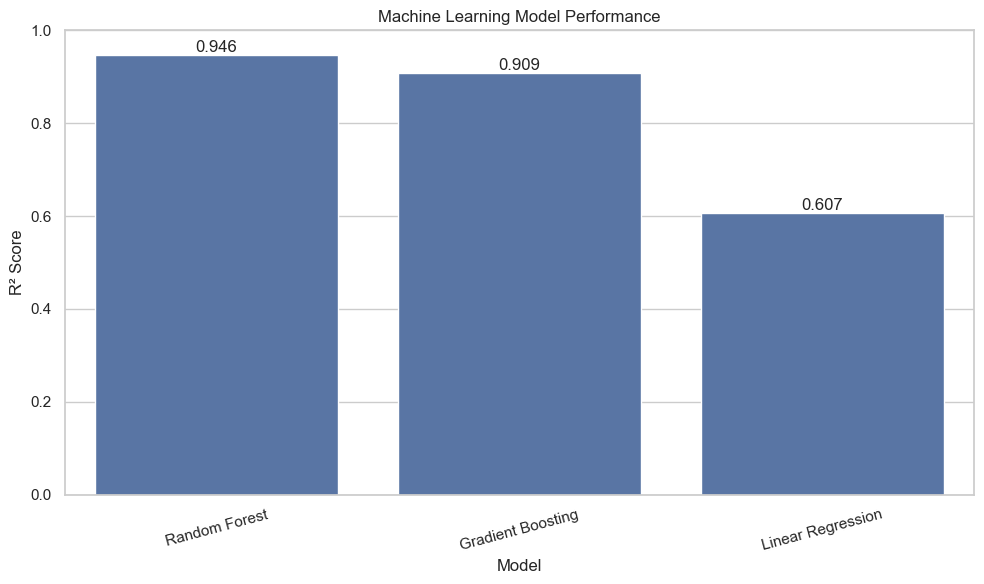

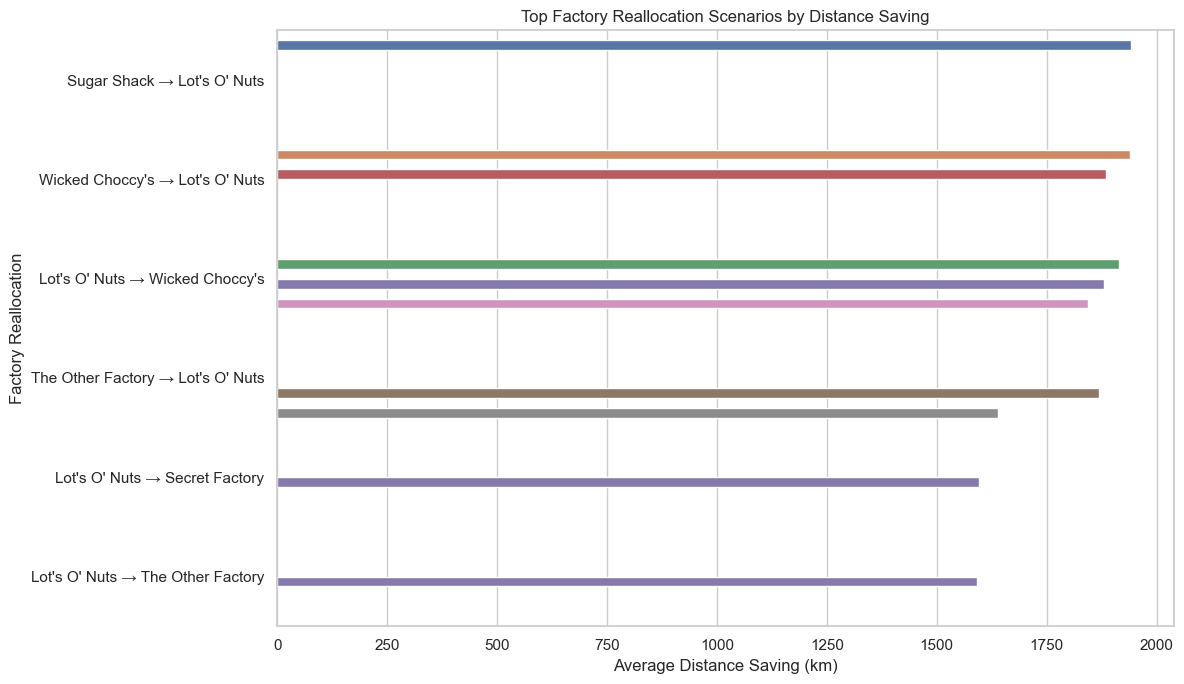

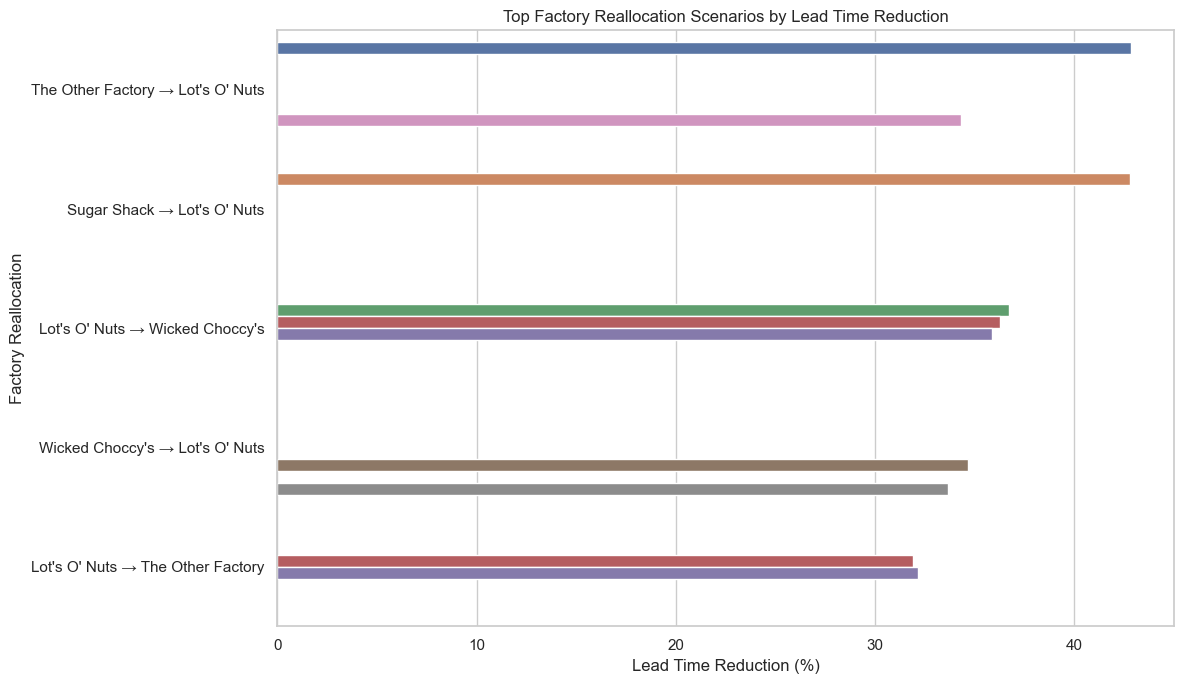

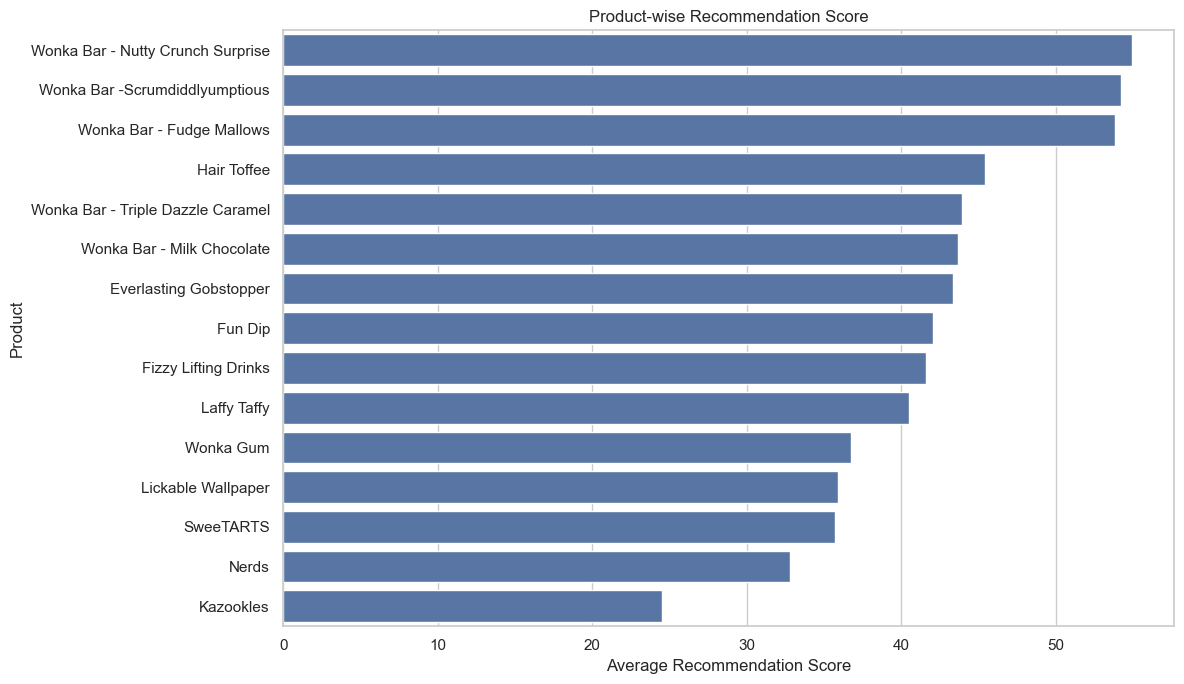

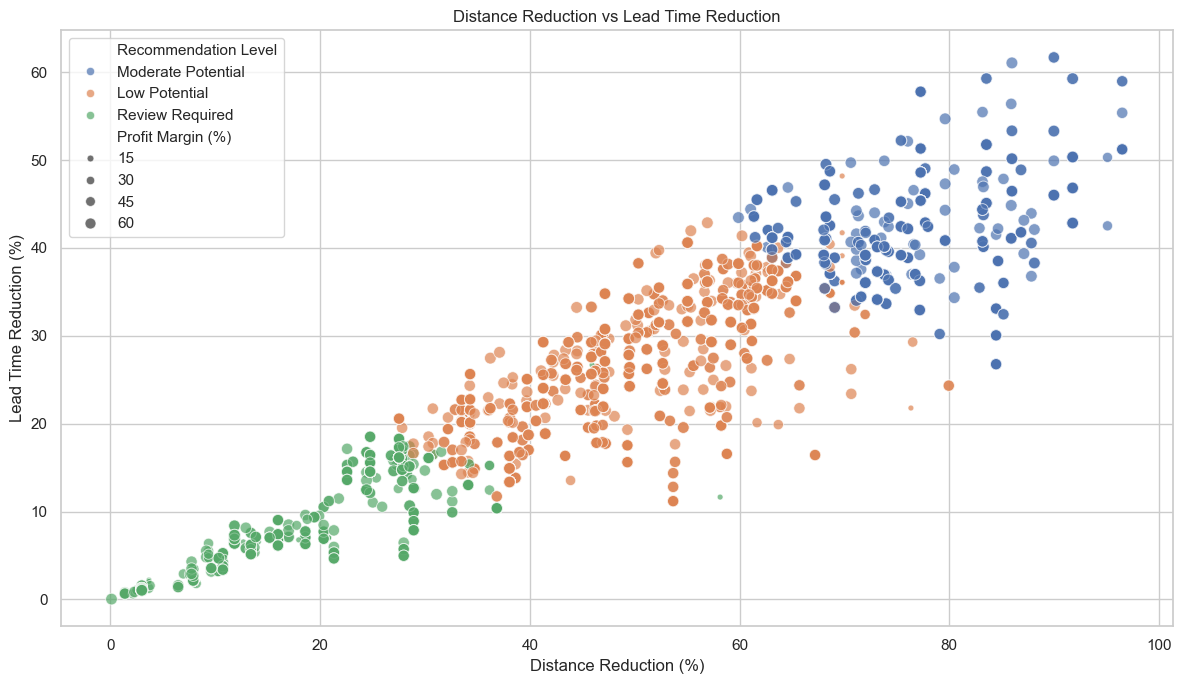

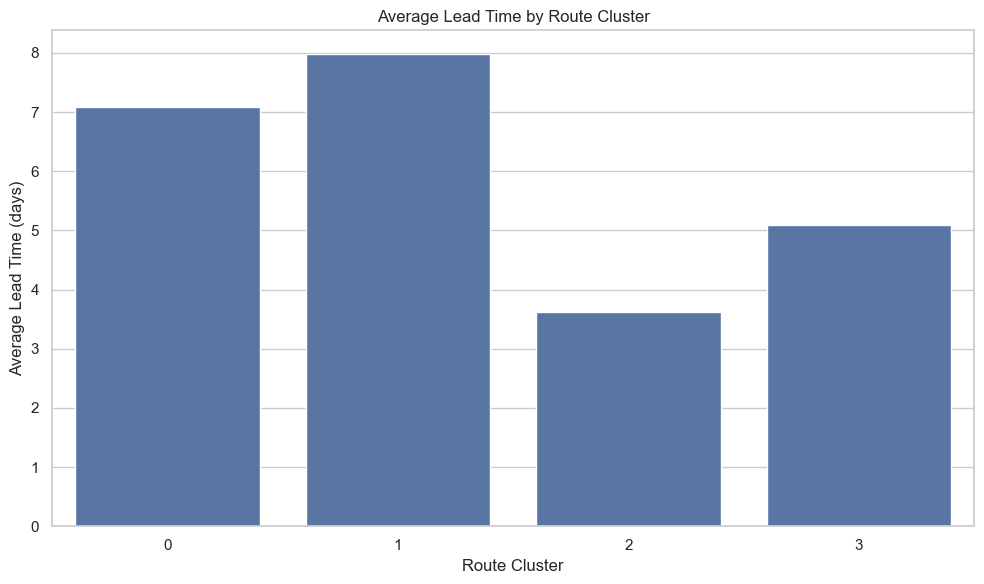

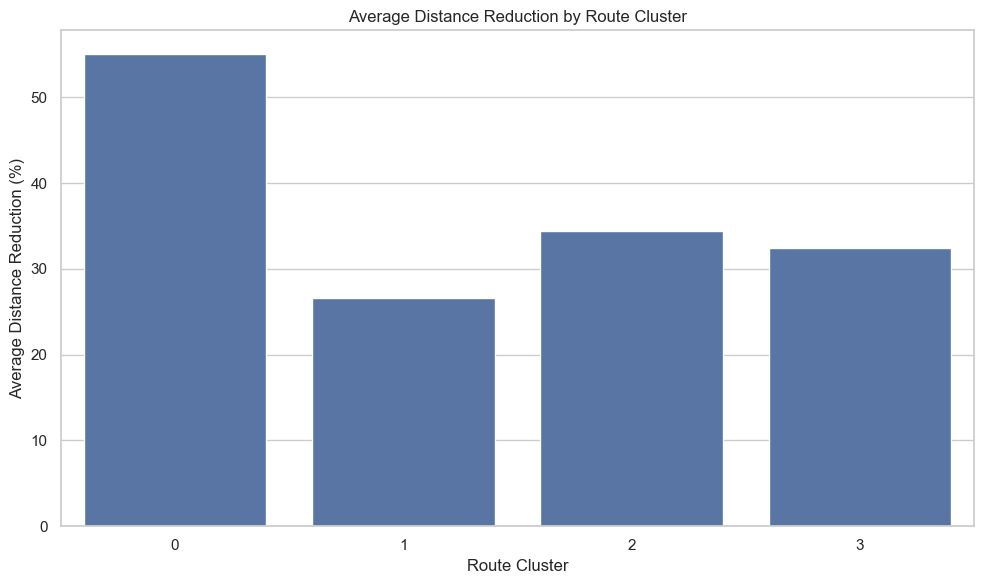

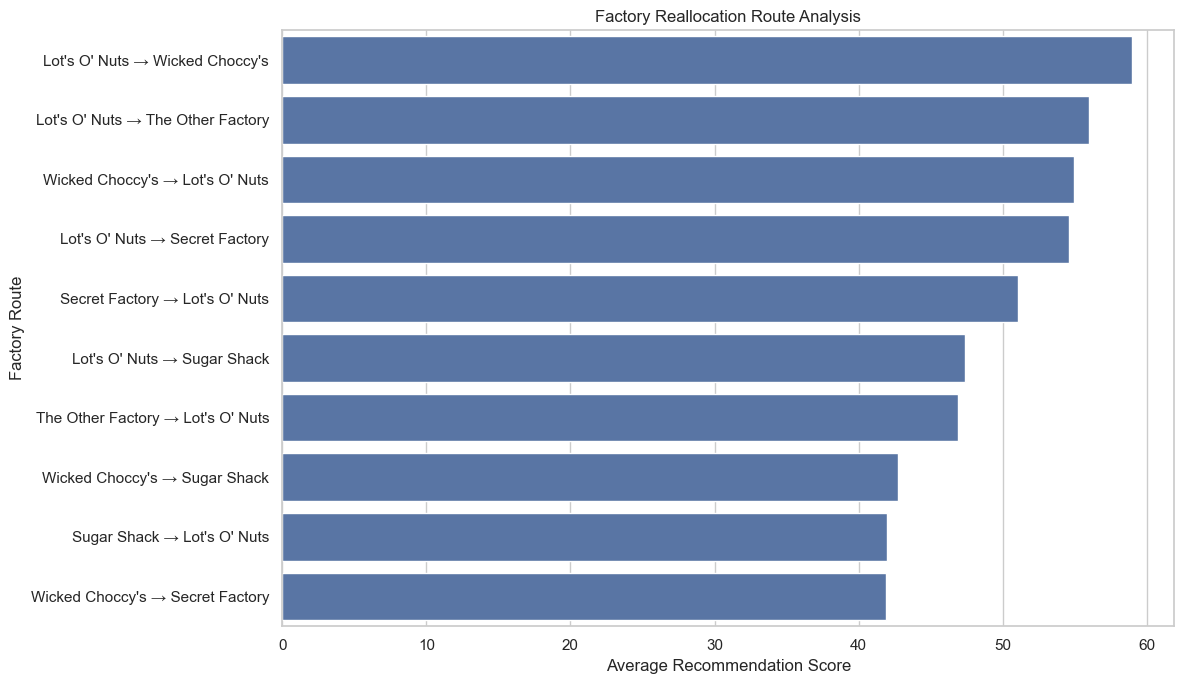

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=model_results_df,
    x="Model",
    y="R2",
    ax=ax
)

ax.set_title("Machine Learning Model Performance")
ax.set_xlabel("Model")
ax.set_ylabel("R² Score")
ax.set_ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


top_distance = (
    final_recommendations
    .groupby(
        ["Product Name", "Current Factory", "Alternative Factory"],
        as_index=False
    )
    .agg(
        Distance_Saving_km=("Distance Saving (km)", "mean"),
        Distance_Reduction_pct=("Distance Reduction (%)", "mean")
    )
    .sort_values(
        "Distance_Saving_km",
        ascending=False
    )
    .head(10)
)

top_distance["Route"] = (
    top_distance["Current Factory"]
    + " → "
    + top_distance["Alternative Factory"]
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=top_distance,
    y="Route",
    x="Distance_Saving_km",
    hue="Product Name",
    ax=ax,
    legend=False
)

ax.set_title("Top Factory Reallocation Scenarios by Distance Saving")
ax.set_xlabel("Average Distance Saving (km)")
ax.set_ylabel("Factory Reallocation")

plt.tight_layout()
plt.show()


top_lead = (
    final_recommendations
    .groupby(
        ["Product Name", "Current Factory", "Alternative Factory"],
        as_index=False
    )
    .agg(
        Lead_Time_Reduction_pct=("Lead Time Reduction (%)", "mean")
    )
    .sort_values(
        "Lead_Time_Reduction_pct",
        ascending=False
    )
    .head(10)
)

top_lead["Route"] = (
    top_lead["Current Factory"]
    + " → "
    + top_lead["Alternative Factory"]
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=top_lead,
    y="Route",
    x="Lead_Time_Reduction_pct",
    hue="Product Name",
    ax=ax,
    legend=False
)

ax.set_title("Top Factory Reallocation Scenarios by Lead Time Reduction")
ax.set_xlabel("Lead Time Reduction (%)")
ax.set_ylabel("Factory Reallocation")

plt.tight_layout()
plt.show()


product_analysis = (
    final_recommendations
    .groupby("Product Name", as_index=False)
    .agg(
        Avg_Lead_Time_Reduction=("Lead Time Reduction (%)", "mean"),
        Avg_Distance_Reduction=("Distance Reduction (%)", "mean"),
        Avg_Profit_Margin=("Profit Margin (%)", "mean"),
        Avg_Recommendation_Score=("Final Recommendation Score", "mean")
    )
    .sort_values(
        "Avg_Recommendation_Score",
        ascending=False
    )
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=product_analysis,
    y="Product Name",
    x="Avg_Recommendation_Score",
    ax=ax
)

ax.set_title("Product-wise Recommendation Score")
ax.set_xlabel("Average Recommendation Score")
ax.set_ylabel("Product")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=final_recommendations.sample(
        min(3000, len(final_recommendations)),
        random_state=42
    ),
    x="Distance Reduction (%)",
    y="Lead Time Reduction (%)",
    size="Profit Margin (%)",
    hue="Recommendation Level",
    alpha=0.7,
    ax=ax
)

ax.set_title("Distance Reduction vs Lead Time Reduction")
ax.set_xlabel("Distance Reduction (%)")
ax.set_ylabel("Lead Time Reduction (%)")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=cluster_summary,
    x="Route Cluster",
    y="Avg_Lead_Time_days",
    ax=ax
)

ax.set_title("Average Lead Time by Route Cluster")
ax.set_xlabel("Route Cluster")
ax.set_ylabel("Average Lead Time (days)")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=cluster_summary,
    x="Route Cluster",
    y="Avg_Distance_Reduction_pct",
    ax=ax
)

ax.set_title("Average Distance Reduction by Route Cluster")
ax.set_xlabel("Route Cluster")
ax.set_ylabel("Average Distance Reduction (%)")

plt.tight_layout()
plt.show()


factory_analysis = (
    final_recommendations
    .groupby(
        ["Current Factory", "Alternative Factory"],
        as_index=False
    )
    .agg(
        Avg_Distance_Saving=("Distance Saving (km)", "mean"),
        Avg_Distance_Reduction=("Distance Reduction (%)", "mean"),
        Avg_Lead_Time_Reduction=("Lead Time Reduction (%)", "mean"),
        Avg_Profit_Margin=("Profit Margin (%)", "mean"),
        Avg_Score=("Final Recommendation Score", "mean")
    )
)

factory_analysis["Route"] = (
    factory_analysis["Current Factory"]
    + " → "
    + factory_analysis["Alternative Factory"]
)

factory_analysis = factory_analysis.sort_values(
    "Avg_Score",
    ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=factory_analysis,
    y="Route",
    x="Avg_Score",
    ax=ax
)

ax.set_title("Factory Reallocation Route Analysis")
ax.set_xlabel("Average Recommendation Score")
ax.set_ylabel("Factory Route")

plt.tight_layout()
plt.show()

In [21]:
top_recommendation = final_recommendations.iloc[0]

best_model_row = model_results_df.iloc[0]

best_distance_route = (
    final_recommendations
    .groupby(
        ["Product Name", "Current Factory", "Alternative Factory"],
        as_index=False
    )
    .agg(
        Avg_Distance_Saving=("Distance Saving (km)", "mean"),
        Avg_Distance_Reduction=("Distance Reduction (%)", "mean")
    )
    .sort_values(
        "Avg_Distance_Saving",
        ascending=False
    )
    .iloc[0]
)

best_lead_route = (
    final_recommendations
    .groupby(
        ["Product Name", "Current Factory", "Alternative Factory"],
        as_index=False
    )
    .agg(
        Avg_Lead_Time_Saving=("Lead Time Saving (days)", "mean"),
        Avg_Lead_Time_Reduction=("Lead Time Reduction (%)", "mean")
    )
    .sort_values(
        "Avg_Lead_Time_Reduction",
        ascending=False
    )
    .iloc[0]
)

print("=" * 70)
print("NASSAU CANDY FACTORY OPTIMIZATION")
print("EXECUTIVE BUSINESS INSIGHTS")
print("=" * 70)

print("\n1. DATASET OVERVIEW")
print("-" * 70)
print("Total Orders:", df_clean["Order ID"].nunique())
print("Total Products:", df_clean["Product Name"].nunique())
print("Total Customers:", df_clean["Customer ID"].nunique())
print("Total Sales:", round(df_clean["Sales"].sum(), 2))
print("Total Gross Profit:", round(df_clean["Gross Profit"].sum(), 2))

print("\n2. DISTANCE OPTIMIZATION")
print("-" * 70)
print(
    "Average Current Distance:",
    round(df_clean["Current Distance (km)"].mean(), 2),
    "km"
)
print(
    "Average Potential Distance Saving:",
    round(df_clean["Potential Distance Saving (km)"].mean(), 2),
    "km"
)
print(
    "Average Potential Distance Reduction:",
    round(df_clean["Potential Distance Reduction (%)"].mean(), 2),
    "%"
)

print("\n3. LEAD TIME OPTIMIZATION")
print("-" * 70)
print(
    "Average Scenario Lead Time Reduction:",
    round(
        scenario_df["Lead Time Reduction (%)"].mean(),
        2
    ),
    "%"
)

print(
    "Best Lead-Time Scenario:",
    best_lead_route["Product Name"]
)

print(
    "Route:",
    best_lead_route["Current Factory"],
    "→",
    best_lead_route["Alternative Factory"]
)

print(
    "Lead-Time Reduction:",
    round(
        best_lead_route["Avg_Lead_Time_Reduction"],
        2
    ),
    "%"
)

print("\n4. DISTANCE SAVING OPPORTUNITY")
print("-" * 70)

print(
    "Product:",
    best_distance_route["Product Name"]
)

print(
    "Route:",
    best_distance_route["Current Factory"],
    "→",
    best_distance_route["Alternative Factory"]
)

print(
    "Average Distance Saving:",
    round(
        best_distance_route["Avg_Distance_Saving"],
        2
    ),
    "km"
)

print(
    "Distance Reduction:",
    round(
        best_distance_route["Avg_Distance_Reduction"],
        2
    ),
    "%"
)

print("\n5. MACHINE LEARNING")
print("-" * 70)

print(
    "Best Model:",
    best_model_name
)

print(
    "RMSE:",
    round(
        best_model_row["RMSE"],
        4
    )
)

print(
    "MAE:",
    round(
        best_model_row["MAE"],
        4
    )
)

print(
    "R²:",
    round(
        best_model_row["R2"],
        4
    )
)

print("\n6. TOP RECOMMENDATION SCENARIO")
print("-" * 70)

print(
    "Product:",
    top_recommendation["Product Name"]
)

print(
    "Current Factory:",
    top_recommendation["Current Factory"]
)

print(
    "Alternative Factory:",
    top_recommendation["Alternative Factory"]
)

print(
    "Current Lead Time:",
    round(
        top_recommendation["Current Lead Time (days)"],
        2
    ),
    "days"
)

print(
    "Alternative Lead Time:",
    round(
        top_recommendation["Alternative Lead Time (days)"],
        2
    ),
    "days"
)

print(
    "Lead Time Saving:",
    round(
        top_recommendation["Lead Time Saving (days)"],
        2
    ),
    "days"
)

print(
    "Lead Time Reduction:",
    round(
        top_recommendation["Lead Time Reduction (%)"],
        2
    ),
    "%"
)

print(
    "Distance Saving:",
    round(
        top_recommendation["Distance Saving (km)"],
        2
    ),
    "km"
)

print(
    "Distance Reduction:",
    round(
        top_recommendation["Distance Reduction (%)"],
        2
    ),
    "%"
)

print(
    "Profit Margin:",
    round(
        top_recommendation["Profit Margin (%)"],
        2
    ),
    "%"
)

print(
    "Recommendation Score:",
    round(
        top_recommendation["Final Recommendation Score"],
        2
    )
)

print(
    "Recommendation Level:",
    top_recommendation["Recommendation Level"]
)

print("\n7. PROJECT INTERPRETATION")
print("-" * 70)

print(
    "The analysis identifies factory reallocation scenarios that can "
    "reduce estimated transportation distance and scenario-based lead time."
)

print(
    "The recommendation engine combines lead-time reduction, "
    "distance reduction, profit margin and scenario confidence."
)

print(
    "The route clustering analysis groups product-region-shipping "
    "combinations based on distance, lead time and profitability indicators."
)

print(
    "The machine-learning models estimate scenario-based shipping "
    "lead time rather than historical operational lead time."
)

print("\n" + "=" * 70)
print("EXECUTIVE SUMMARY COMPLETED")
print("=" * 70)

NASSAU CANDY FACTORY OPTIMIZATION
EXECUTIVE BUSINESS INSIGHTS

1. DATASET OVERVIEW
----------------------------------------------------------------------
Total Orders: 8549
Total Products: 15
Total Customers: 5044
Total Sales: 141783.63
Total Gross Profit: 93442.8

2. DISTANCE OPTIMIZATION
----------------------------------------------------------------------
Average Current Distance: 1995.66 km
Average Potential Distance Saving: 1167.72 km
Average Potential Distance Reduction: 44.95 %

3. LEAD TIME OPTIMIZATION
----------------------------------------------------------------------
Average Scenario Lead Time Reduction: 26.51 %
Best Lead-Time Scenario: Hair Toffee
Route: The Other Factory → Lot's O' Nuts
Lead-Time Reduction: 42.86 %

4. DISTANCE SAVING OPPORTUNITY
----------------------------------------------------------------------
Product: Fizzy Lifting Drinks
Route: Sugar Shack → Lot's O' Nuts
Average Distance Saving: 1942.55 km
Distance Reduction: 95.13 %

5. MACHINE LEARNING
-----